In [1]:
import numpy as np
import pandas as pd
from datetime import datetime
import matplotlib.pyplot as plt
import math
import matplotlib.dates as mdates
import matplotlib as mpl
mpl.rcParams['xtick.labelsize'] = 12
mpl.rcParams['ytick.labelsize'] = 12

In [2]:
surprises = pd.read_excel('Data_Raw.xlsx',sheet_name='Surprises')
surprises.columns = ['Date','EA Inflation Raw','EA Growth Raw','US Inflation Raw','US Growth Raw',]
surprises['Date'] = pd.to_datetime(surprises['Date'])
surprises.sort_values(by='Date',inplace=True)
surprises.reset_index(drop=True,inplace=True)

swapestr_ds = pd.read_excel('Data_Raw.xlsx',sheet_name='SwapEstrDS')
swapestr_ds['Date'] = pd.to_datetime(swapestr_ds['Date'])
swapestr_ds.columns = ['Date','SwapESTR1M','SwapESTR3M','SwapESTR6M','SwapESTR1Y']
swapestr_ds.sort_values(by='Date',inplace=True)
swapestr_ds.reset_index(drop=True,inplace=True)

swapestr_citi = pd.read_excel('Data_Raw.xlsx',sheet_name='SwapEstrCITI')
swapestr_citi['Date'] = pd.to_datetime(swapestr_citi['Date'])
swapestr_citi.columns = ['Date','SwapESTR2Y','SwapESTR5Y','SwapESTR10Y','SwapESTR30Y']
swapestr_citi.sort_values(by='Date',inplace=True)
swapestr_citi.reset_index(drop=True,inplace=True)

oas = pd.read_excel('Data_Raw.xlsx',sheet_name='OAS')
oas['Date'] = pd.to_datetime(oas['Date'])
oas.columns = ['Date','OAS']
oas.sort_values(by='Date',inplace=True)
oas.reset_index(drop=True,inplace=True)

data_path = r'\\osiride-fs\group\main\891af\private\Area_MF\Varie\Poli_Venturi\RiskNeutralDensities\Densities\Uncertainty_Indicator_1090_12month.xlsx'
uncertainty = pd.read_excel(data_path)
uncertainty.columns = ['Date','Uncertainty']
uncertainty['Date'] = pd.to_datetime(uncertainty['Date'])
uncertainty.sort_values(by='Date',inplace=True)
uncertainty.reset_index(drop=True,inplace=True)

In [3]:
data_path = r'\\osiride-fs\group\main\891af\private\Area_MF\Varie\Poli_Venturi\Data\acmDecomposition.xlsx'

acm_yield = pd.read_excel(data_path,sheet_name='ACM_Yields',parse_dates=True)
acm_yield.columns = ['Date','1Y','2Y','3Y','4Y','5Y','6Y','7Y','8Y','9Y','10Y']
acm_yield['Date'] = pd.to_datetime(acm_yield['Date'])
acm_yield.sort_values(by='Date',inplace=True)
acm_yield.reset_index(drop=True,inplace=True)

acm_tp = pd.read_excel(data_path,sheet_name='ACM_TermPremium')
acm_tp.columns = ['Date','TP_1Y','TP_2Y','TP_3Y','TP_4Y','TP_5Y','TP_6Y','TP_7Y','TP_8Y','TP_9Y','TP_10Y']
acm_tp['Date'] = pd.to_datetime(acm_tp['Date'])
acm_tp.sort_values(by='Date',inplace=True)
acm_tp.reset_index(drop=True,inplace=True)

acm_rn = pd.read_excel(data_path,sheet_name='ACM_RiskNeutralYields')
acm_rn.columns = ['Date','RN_1Y','RN_2Y','RN_3Y','RN_4Y','RN_5Y','RN_6Y','RN_7Y','RN_8Y','RN_9Y','RN_10Y']
acm_rn['Date'] = pd.to_datetime(acm_rn['Date'])
acm_rn.sort_values(by='Date',inplace=True)
acm_rn.reset_index(drop=True,inplace=True)

acm = acm_yield.merge(acm_tp,how='inner',on='Date')
acm = acm.merge(acm_rn,how='inner',on='Date')

In [4]:
# Compute Raw Standardised Surprises from BBG index
alpha = 0.995

US_inf = surprises['US Inflation Raw']
US_grw = surprises['US Growth Raw']
EA_inf = surprises['EA Inflation Raw']
EA_grw = surprises['EA Growth Raw']
US_inf_clean = list()
US_grw_clean = list()
EA_inf_clean = list()
EA_grw_clean = list()

for i in range(0,len(surprises)):
    if i == 0:
        US_inf_clean.append(np.nan)
        US_grw_clean.append(np.nan)
        EA_inf_clean.append(np.nan)
        EA_grw_clean.append(np.nan)
    else:
        US_inf_clean.append(US_inf[i] - alpha*US_inf[i-1])
        US_grw_clean.append(US_grw[i] - alpha*US_grw[i-1])
        EA_inf_clean.append(EA_inf[i] - alpha*EA_inf[i-1])
        EA_grw_clean.append(EA_grw[i] - alpha*EA_grw[i-1])

Surprises = pd.DataFrame(data={'Date':surprises.Date, 
                               'USInflation':US_inf_clean, 'USGrowth':US_grw_clean,
                               'EAInflation':EA_inf_clean, 'EAGrowth':EA_grw_clean})

# Aggregate Surprises
#### Arrotondare il valore della sorpresa a 4 decimali per eliminare giornate senza sorprese.
#### Procedure numerica di rimozione del filtro BBG genera giornate con sorprese (es. 0.05 e-6)
Surprises = round(Surprises,4)
Surprises['USSurprise'] = Surprises['USInflation'] + Surprises['USGrowth']
Surprises['EASurprise'] = Surprises['EAInflation'] + Surprises['EAGrowth']

In [5]:
data = Surprises.merge(swapestr_ds,on='Date',how='outer')
data = data.merge(swapestr_citi,on='Date',how='outer')
data = data.merge(oas,on='Date',how='outer')
data = data.merge(uncertainty,on='Date',how='outer')
data = data.merge(acm,on='Date',how='outer')

In [6]:
# Extract Dates
Time = pd.to_datetime(data['Date'])

# Compute Daily Rate Differences
data['OASd'] = data['OAS'].diff(periods=1)
data['SwapESTR6Md'] = data['SwapESTR6M'].diff(periods=1)*100
# data['SwapESTR1Yd'] = data['SwapESTR1Y'].diff(periods=1)*100
data['SwapESTR2Yd'] = data['SwapESTR2Y'].diff(periods=1)*100
data['SwapESTR5Yd'] = data['SwapESTR5Y'].diff(periods=1)*100
data['SwapESTR10Yd'] = data['SwapESTR10Y'].diff(periods=1)*100
data['2Yd'] = data['2Y'].diff(periods=1)*100
data['5Yd'] = data['5Y'].diff(periods=1)*100
data['10Yd'] = data['10Y'].diff(periods=1)*100
data['RN_2Yd'] = data['RN_2Y'].diff(periods=1)*100
data['RN_5Yd'] = data['RN_5Y'].diff(periods=1)*100
data['RN_10Yd'] = data['RN_10Y'].diff(periods=1)*100
data['TP_2Yd'] = data['TP_2Y'].diff(periods=1)*100
data['TP_5Yd'] = data['TP_5Y'].diff(periods=1)*100
data['TP_10Yd'] = data['TP_10Y'].diff(periods=1)*100

# Compute Momentum
data['SwapESTR6Mm'] = data['SwapESTR6M'].diff(periods=10)*100
data['SwapESTR2Ym'] = data['SwapESTR2Y'].diff(periods=10)*100
data['SwapESTR5Ym'] = data['SwapESTR5Y'].diff(periods=10)*100
data['SwapESTR10Ym'] = data['SwapESTR10Y'].diff(periods=10)*100
data['2Ym'] = data['2Y'].diff(periods=10)*100
data['5Ym'] = data['5Y'].diff(periods=10)*100
data['10Ym'] = data['10Y'].diff(periods=10)*100
data['RN_2Ym'] = data['RN_2Y'].diff(periods=10)*100
data['RN_5Ym'] = data['RN_5Y'].diff(periods=10)*100
data['RN_10Ym'] = data['RN_10Y'].diff(periods=10)*100
data['TP_2Ym'] = data['TP_2Y'].diff(periods=10)*100
data['TP_5Ym'] = data['TP_5Y'].diff(periods=10)*100
data['TP_10Ym'] = data['TP_10Y'].diff(periods=10)*100

In [7]:
data.set_index('Date',inplace=True,drop=True)
data.to_excel('Database_Regression.xlsx',index=True,header=True)

### Plots

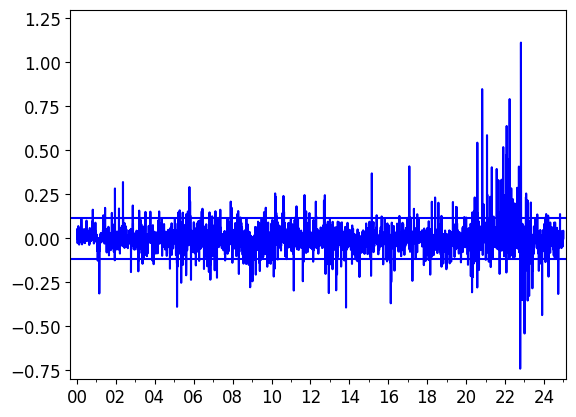

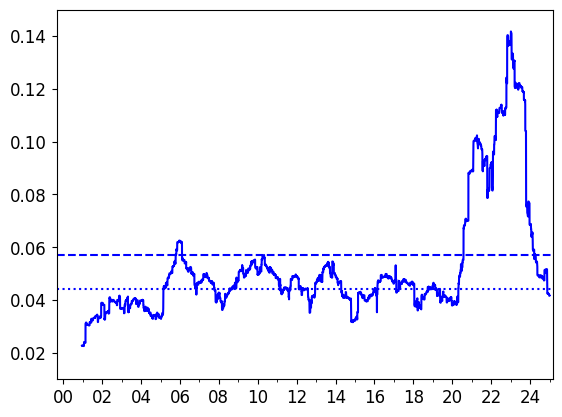

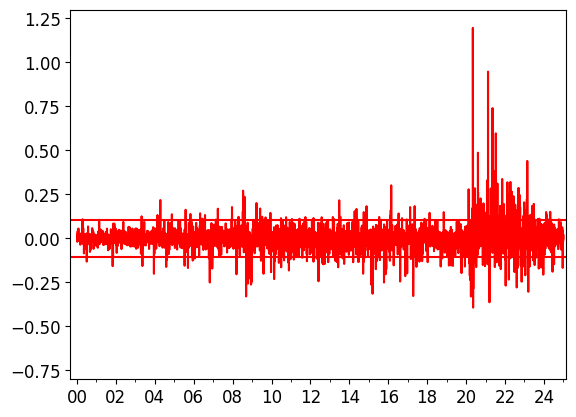

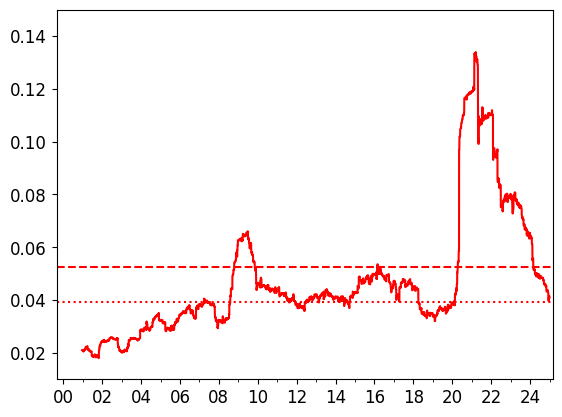

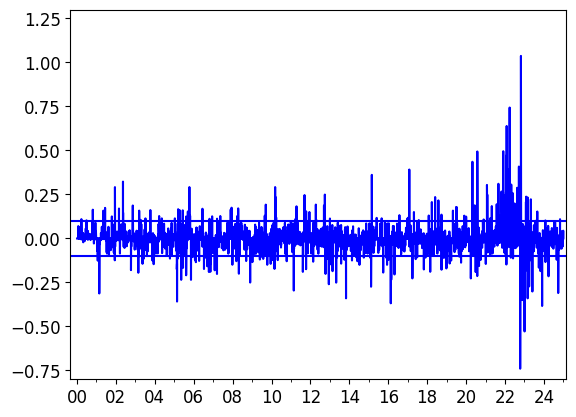

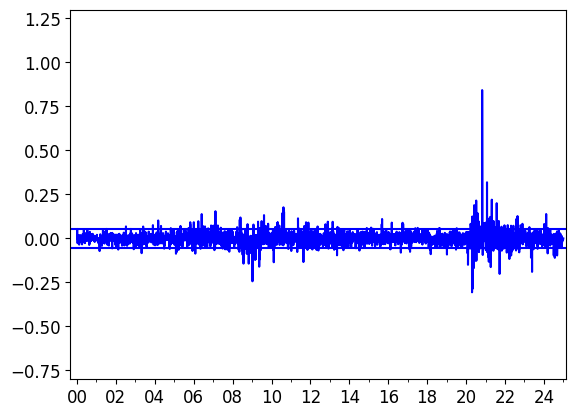

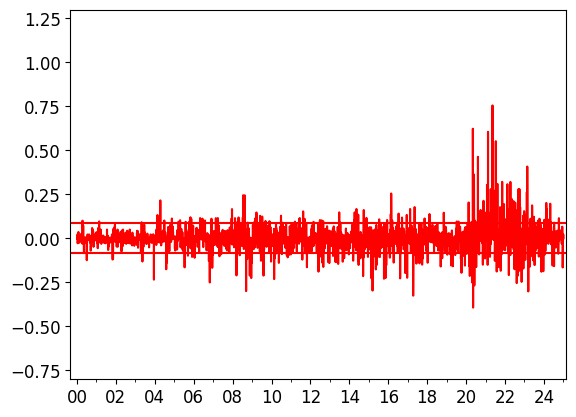

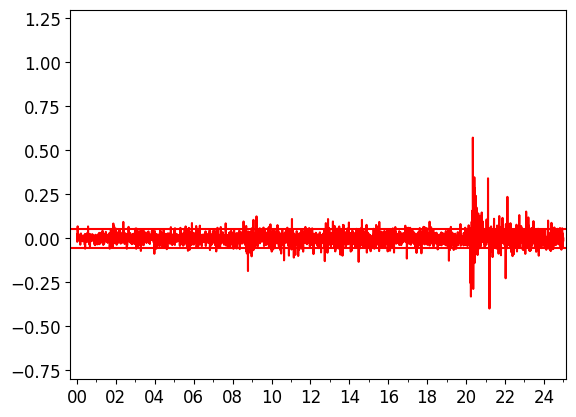

In [8]:
data = data.loc[datetime(2000,1,1):datetime(2025,1,1)]

ymax = 1.30 
ymin = -0.8
biyear = mdates.YearLocator(2)
year = mdates.YearLocator(1)
fmt = mdates.DateFormatter('%y')

EA_rol = data['EASurprise'].rolling(window=252)
US_rol = data['USSurprise'].rolling(window=252)

fig,ax = plt.subplots(1,1)
ax.plot(data.index,data['EASurprise'],color='blue')
ax.axhline(data['EASurprise'].std()*2,color='blue')
ax.axhline(data['EASurprise'].std()*-2,color='blue')
ax.set_ylim([ymin,ymax])
ax.set_xlim([datetime(1999,9,1),datetime(2025,3,1)])
ax.xaxis.set_major_locator(biyear)
ax.xaxis.set_minor_locator(year)
ax.xaxis.set_major_formatter(fmt)
plt.savefig(r'\\osiride-fs\group\main\891af\private\Area_MF\Varie\Poli_Venturi\Output\EA_surprises.png',dpi=200,bbox_inches='tight')

fig,ax = plt.subplots(1,1)
ax.plot(data.index,EA_rol.std(),color='blue')
ax.axhline(data['EASurprise'].std(),color='blue',linestyle='--')
ax.axhline(data.loc[:datetime(2020,1,1),'EASurprise'].std(),color='blue',linestyle=':')
ax.set_ylim([0.01,0.15])
ax.set_xlim([datetime(1999,9,1),datetime(2025,3,1)])
ax.xaxis.set_major_locator(biyear)
ax.xaxis.set_minor_locator(year)
ax.xaxis.set_major_formatter(fmt)
plt.savefig(r'\\osiride-fs\group\main\891af\private\Area_MF\Varie\Poli_Venturi\Output\EA_volatility.png',dpi=200,bbox_inches='tight')

fig,ax = plt.subplots(1,1)
ax.plot(data.index,data['USSurprise'],color='red')
ax.axhline(data['USSurprise'].std()*2,color='red')
ax.axhline(data['USSurprise'].std()*-2,color='red')
ax.set_ylim([ymin,ymax])
ax.set_xlim([datetime(1999,9,1),datetime(2025,3,1)])
ax.xaxis.set_major_locator(biyear)
ax.xaxis.set_minor_locator(year)
ax.xaxis.set_major_formatter(fmt)
plt.savefig(r'\\osiride-fs\group\main\891af\private\Area_MF\Varie\Poli_Venturi\Output\US_surprises.png',dpi=200,bbox_inches='tight')

fig,ax = plt.subplots(1,1)
ax.plot(data.index,US_rol.std(),color='red')
ax.axhline(data['USSurprise'].std(),color='red',linestyle='--')
ax.axhline(data.loc[:datetime(2020,1,1),'USSurprise'].std(),color='red',linestyle=':')
ax.set_ylim([0.01,0.15])
ax.set_xlim([datetime(1999,9,1),datetime(2025,3,1)])
ax.xaxis.set_major_locator(biyear)
ax.xaxis.set_minor_locator(year)
ax.xaxis.set_major_formatter(fmt)
plt.savefig(r'\\osiride-fs\group\main\891af\private\Area_MF\Varie\Poli_Venturi\Output\US_volatility.png',dpi=200,bbox_inches='tight')

fig,ax = plt.subplots(1,1)
ax.plot(data.index,data['EAInflation'],color='blue')
ax.axhline(data['EAInflation'].std()*2,color='blue')
ax.axhline(data['EAInflation'].std()*-2,color='blue')
ax.set_ylim([ymin,ymax])
ax.set_xlim([datetime(1999,9,1),datetime(2025,3,1)])
ax.xaxis.set_major_locator(biyear)
ax.xaxis.set_minor_locator(year)
ax.xaxis.set_major_formatter(fmt)
plt.savefig(r'\\osiride-fs\group\main\891af\private\Area_MF\Varie\Poli_Venturi\Output\EA_inflation.png',dpi=200,bbox_inches='tight')

fig,ax = plt.subplots(1,1)
ax.plot(data.index,data['EAGrowth'],color='blue')
ax.axhline(data['EAGrowth'].std()*2,color='blue')
ax.axhline(data['EAGrowth'].std()*-2,color='blue')
ax.set_ylim([ymin,ymax])
ax.set_xlim([datetime(1999,9,1),datetime(2025,3,1)])
ax.xaxis.set_major_locator(biyear)
ax.xaxis.set_minor_locator(year)
ax.xaxis.set_major_formatter(fmt)
plt.savefig(r'\\osiride-fs\group\main\891af\private\Area_MF\Varie\Poli_Venturi\Output\EA_growth.png',dpi=200,bbox_inches='tight')

fig,ax = plt.subplots(1,1)
ax.plot(data.index,data['USInflation'],color='red')
ax.axhline(data['USInflation'].std()*2,color='red')
ax.axhline(data['USInflation'].std()*-2,color='red')
ax.set_ylim([ymin,ymax])
ax.set_xlim([datetime(1999,9,1),datetime(2025,3,1)])
ax.xaxis.set_major_locator(biyear)
ax.xaxis.set_minor_locator(year)
ax.xaxis.set_major_formatter(fmt)
plt.savefig(r'\\osiride-fs\group\main\891af\private\Area_MF\Varie\Poli_Venturi\Output\US_inflation.png',dpi=200,bbox_inches='tight')

fig,ax = plt.subplots(1,1)
ax.plot(data.index,data['USGrowth'],color='red')
ax.axhline(data['USGrowth'].std()*2,color='red')
ax.axhline(data['USGrowth'].std()*-2,color='red')
ax.set_ylim([ymin,ymax])
ax.set_xlim([datetime(1999,9,1),datetime(2025,3,1)])
ax.xaxis.set_major_locator(biyear)
ax.xaxis.set_minor_locator(year)
ax.xaxis.set_major_formatter(fmt)
plt.savefig(r'\\osiride-fs\group\main\891af\private\Area_MF\Varie\Poli_Venturi\Output\US_growth.png',dpi=200,bbox_inches='tight')